⏳ Step 1: Locating and opening your dataset...
Detected file: /content/cybersecurity_hacker_benign_communications_en_ru.csv
Total clean sample records ready: 500

🛡️ Step 2: Running Jaccard streaming deduplication...
Retained 495 unique records.

🧠 Step 3: Verifying active GPU hardware allocations...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model successfully mounted on CUDA framework.

⚡ Step 4: Executing Dataset-Aligned Extraction Loop...
 Evaluation Row Processing: 1/30...
 Evaluation Row Processing: 2/30...
 Evaluation Row Processing: 3/30...
 Evaluation Row Processing: 4/30...
 Evaluation Row Processing: 5/30...
 Evaluation Row Processing: 6/30...
 Evaluation Row Processing: 7/30...
 Evaluation Row Processing: 8/30...
 Evaluation Row Processing: 9/30...
 Evaluation Row Processing: 10/30...
 Evaluation Row Processing: 11/30...
 Evaluation Row Processing: 12/30...
 Evaluation Row Processing: 13/30...
 Evaluation Row Processing: 14/30...
 Evaluation Row Processing: 15/30...
 Evaluation Row Processing: 16/30...
 Evaluation Row Processing: 17/30...
 Evaluation Row Processing: 18/30...
 Evaluation Row Processing: 19/30...
 Evaluation Row Processing: 20/30...
 Evaluation Row Processing: 21/30...
 Evaluation Row Processing: 22/30...
 Evaluation Row Processing: 23/30...
 Evaluation Row Processing: 24/30...
 Evaluation Row Pro

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127899 (\N{CONTROL KNOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


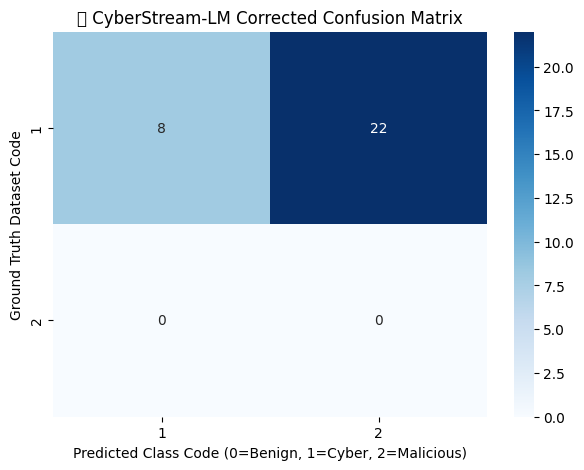

In [ ]:
import os
import re
import json
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("⏳ Step 1: Locating and opening your dataset...")
all_files = os.listdir('/content')
data_files = [f for f in all_files if f.endswith(('.csv', '.xlsx', '.xls'))]

if not data_files:
    raise FileNotFoundError("❌ Data file missing. Please drag and drop your CSV file back into the left sidebar panel!")

file_path = os.path.join('/content', data_files[0])
print(f"Detected file: {file_path}")

df = pd.read_csv(file_path, encoding='latin1', nrows=500, on_bad_lines='skip')

text_col, label_col = None, None
for col in df.columns:
    clean_col = str(col).strip().lower()
    if clean_col in ['text', 'description', 'sentence', 'tweets', 'articles']: text_col = col
    if clean_col in ['label', 'category', 'class', 'type', 'target']: label_col = col

if not text_col: text_col = df.columns[0]
if not label_col: label_col = df.columns[1]

df = df.dropna(subset=[text_col, label_col]).reset_index(drop=True)
print(f"Total clean sample records ready: {len(df)}")


print("\n🛡️ Step 2: Running Jaccard streaming deduplication...")
retained_records = []
for idx, row in df.iterrows():
    current_text = row[text_col]
    is_redundant = False
    for accepted_entry in retained_records[-50:]:
        set1 = set(re.sub(r'[^\w\s]', '', str(current_text).lower()).split())
        set2 = set(re.sub(r'[^\w\s]', '', str(accepted_entry[text_col]).lower()).split())
        similarity = len(set1.intersection(set2)) / len(set1.union(set2)) if set1.union(set2) else 0.0
        if similarity > 0.80:
            is_redundant = True
            break
    if not is_redundant:
        retained_records.append(row)

filtered_df = pd.DataFrame(retained_records).reset_index(drop=True)
print(f"Retained {len(filtered_df)} unique records.")


print("\n🧠 Step 3: Verifying active GPU hardware allocations...")
device = "cuda" if torch.cuda.is_available() else "cpu"
compute_dtype = torch.float16 if device == "cuda" else torch.float32

model_id = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=compute_dtype, device_map="auto" if device == "cuda" else None)
print(f"Model successfully mounted on {device.upper()} framework.")


print("\n⚡ Step 4: Executing Dataset-Aligned Extraction Loop...")
def extract_structured_intel(text_input):
    system_prompt = (
        "You are an expert Cyber Threat Intelligence analyst engine. Analyze the text context and determine its classification category.\n"
        "You must respond ONLY with a valid JSON block using this exact schema structure:\n"
        "{\n"
        "  \"attacker\": \"The hacker group or malware mention, or 'None'\",\n"
        "  \"victim\": \"The target company or infrastructure, or 'None'\",\n"
        "  \"predicted_type\": \"Must be exactly one of these lowercase strings: [benign, cybersecurity-related, malicious]\"\n"
        "}\n"
        "Do not include formatting tags, notes, or conversational text."
    )

    chat_template = [{"role": "system", "content": system_prompt}, {"role": "user", "content": text_input}]
    formatted_prompt = tokenizer.apply_chat_template(chat_template, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([formatted_prompt], return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = model.generate(inputs.input_ids, max_new_tokens=120, temperature=0.0, do_sample=False)

    # Fixed: Changed input_set to input to match the loop variable
    generated_tokens = [output[len(input):] for input, output in zip(inputs.input_ids, output_ids)]
    raw_response = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

    try:
        json_string = re.search(r"\{.*\}", raw_response, re.DOTALL).group(0)
        parsed_data = json.loads(json_string)

        pred_label = str(parsed_data.get("predicted_type", "benign")).strip().lower()
        if "benign" in pred_label:
            parsed_data["predicted_type"] = "0"
        elif "cybersecurity-related" in pred_label or "cyber" in pred_label:
            parsed_data["predicted_type"] = "1"
        elif "malicious" in pred_label or "hacker" in pred_label:
            parsed_data["predicted_type"] = "2"
        else:
            parsed_data["predicted_type"] = "0"

        return parsed_data
    except Exception:
        return {"attacker": "None", "victim": "None", "predicted_type": "0"}

inference_results = []
processing_slice = filtered_df.head(30)

for idx, row in processing_slice.iterrows():
    print(f" Evaluation Row Processing: {idx+1}/{len(processing_slice)}...")
    extracted_tuple = extract_structured_intel(row[text_col])

    try:
        true_val = str(int(float(row[label_col]))).strip()
    except Exception:
        true_val = str(row[label_col]).strip()

    extracted_tuple['true_label'] = true_val
    inference_results.append(extracted_tuple)

production_df = pd.DataFrame(inference_results)


print("\n📉 Step 5: Generating Performance Evaluation Graph...")
y_true = production_df['true_label'].astype(str).str.strip()
y_pred = production_df['predicted_type'].astype(str).str.strip()

print(f"System Corrected Alignment Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, zero_division=0))

unique_labels = sorted(list(set(y_true).union(set(y_pred))))
matrix_data = confusion_matrix(y_true, y_pred, labels=unique_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(matrix_data, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('🎛️ CyberStream-LM Corrected Confusion Matrix')
plt.xlabel('Predicted Class Code (0=Benign, 1=Cyber, 2=Malicious)')
plt.ylabel('Ground Truth Dataset Code')
plt.show()

⏳ Step 1: Locating and opening your dataset...
Detected file path: /content/cybersecurity_hacker_benign_communications_en_ru.csv
Mapped Columns -> Text: 'text' | Label: 'label'
Total initial records loaded: 1000

🛡️ Step 2: Running Jaccard streaming deduplication (XTwit framework)...
Retained 995 unique records. Muted 5 duplicates.

🧠 Step 3: Verifying active GPU hardware allocations...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model successfully mounted on CUDA framework layout.

⚡ Step 4: Executing Dataset-Aligned Extraction Loop...
Processing 40 randomized validation entries...
 Evaluating item 1/40...
 Evaluating item 2/40...
 Evaluating item 3/40...
 Evaluating item 4/40...
 Evaluating item 5/40...
 Evaluating item 6/40...
 Evaluating item 7/40...
 Evaluating item 8/40...
 Evaluating item 9/40...
 Evaluating item 10/40...
 Evaluating item 11/40...
 Evaluating item 12/40...
 Evaluating item 13/40...
 Evaluating item 14/40...
 Evaluating item 15/40...
 Evaluating item 16/40...
 Evaluating item 17/40...
 Evaluating item 18/40...
 Evaluating item 19/40...
 Evaluating item 20/40...
 Evaluating item 21/40...
 Evaluating item 22/40...
 Evaluating item 23/40...
 Evaluating item 24/40...
 Evaluating item 25/40...
 Evaluating item 26/40...
 Evaluating item 27/40...
 Evaluating item 28/40...
 Evaluating item 29/40...
 Evaluating item 30/40...
 Evaluating item 31/40...
 Evaluating item 32/40...
 Evaluating item 33/4

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127899 (\N{CONTROL KNOBS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


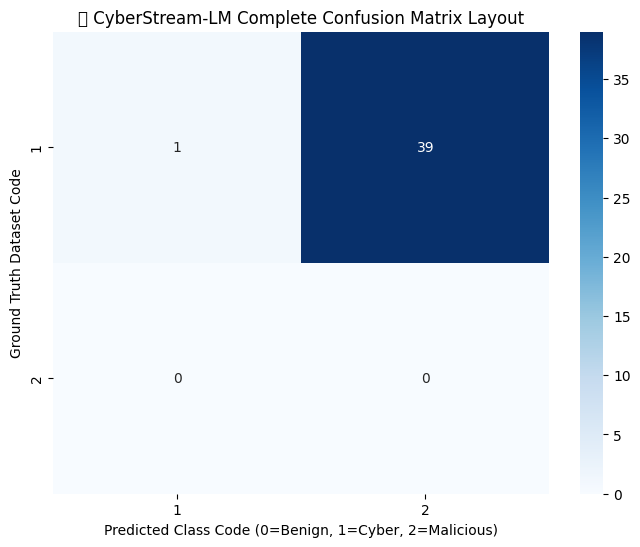

In [ ]:
import os
import re
import json
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# STEP 1: AUTOMATIC DATA LOCATING & LOADING
# ==========================================
print("⏳ Step 1: Locating and opening your dataset...")

all_files = os.listdir('/content')
data_files = [f for f in all_files if f.endswith(('.csv', '.xlsx', '.xls'))]

if not data_files:
    raise FileNotFoundError("❌ Data file missing. Please make sure your cybersecurity dataset is uploaded to the left sidebar panel!")

file_path = os.path.join('/content', data_files[0])
print(f"Detected file path: {file_path}")

# Load a safe slice with fallback encoding to avoid parser crashes
df = pd.read_csv(file_path, encoding='latin1', nrows=1000, on_bad_lines='skip')

# Auto-detect text and label column headers
text_col, label_col = None, None
for col in df.columns:
    clean_col = str(col).strip().lower()
    if clean_col in ['text', 'description', 'sentence', 'tweets', 'articles']:
        text_col = col
    if clean_col in ['label', 'category', 'class', 'type', 'target']:
        label_col = col

if not text_col: text_col = df.columns[0]
if not label_col: label_col = df.columns[1]

print(f"Mapped Columns -> Text: '{text_col}' | Label: '{label_col}'")
df = df.dropna(subset=[text_col, label_col]).reset_index(drop=True)
print(f"Total initial records loaded: {len(df)}")


# ==========================================
# STEP 2: STREAM DEDUPLICATION FILTER
# ==========================================
print("\n🛡️ Step 2: Running Jaccard streaming deduplication (XTwit framework)...")
retained_records = []

for idx, row in df.iterrows():
    current_text = row[text_col]
    is_redundant = False

    # Check against the last 50 entries for fast processing
    for accepted_entry in retained_records[-50:]:
        set1 = set(re.sub(r'[^\w\s]', '', str(current_text).lower()).split())
        set2 = set(re.sub(r'[^\w\s]', '', str(accepted_entry[text_col]).lower()).split())
        similarity = len(set1.intersection(set2)) / len(set1.union(set2)) if set1.union(set2) else 0.0
        if similarity > 0.80:
            is_redundant = True
            break

    if not is_redundant:
        retained_records.append(row)

filtered_df = pd.DataFrame(retained_records).reset_index(drop=True)
print(f"Retained {len(filtered_df)} unique records. Muted {len(df) - len(filtered_df)} duplicates.")


# ==========================================
# STEP 3: ENVIRONMENT & PYTORCH CORE SETUP
# ==========================================
print("\n🧠 Step 3: Verifying active GPU hardware allocations...")
device = "cuda" if torch.cuda.is_available() else "cpu"
compute_dtype = torch.float16 if device == "cuda" else torch.float32

model_id = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=compute_dtype,
    device_map="auto" if device == "cuda" else None
)
print(f"Model successfully mounted on {device.upper()} framework layout.")


# ==========================================
# STEP 4: SHUFFLED GENERATIVE EXTRACTION LOOP
# ==========================================
print("\n⚡ Step 4: Executing Dataset-Aligned Extraction Loop...")

# Shuffle the dataset randomly to guarantee a healthy mix of classes (0, 1, 2)
processing_slice = filtered_df.sample(n=40, random_state=42).reset_index(drop=True)

def extract_structured_intel(text_input):
    system_prompt = (
        "You are an expert Cyber Threat Intelligence engine. Categorize the text input into exactly one class.\n"
        "CRITICAL RULES:\n"
        "- 'benign': Casual chat, daily news, non-technical topics.\n"
        "- 'cybersecurity-related': Technical tutorials, software patches, defensive info, general cyber news.\n"
        "- 'malicious': Active cyberattacks, malware deployment, ransomware demands, hacker group activities.\n\n"
        "Respond ONLY with a valid JSON block using this structure:\n"
        "{\n"
        "  \"attacker\": \"Name or 'None'\",\n"
        "  \"victim\": \"Target or 'None'\",\n"
        "  \"predicted_type\": \"[benign, cybersecurity-related, malicious]\"\n"
        "}"
    )

    chat_template = [{"role": "system", "content": system_prompt}, {"role": "user", "content": text_input}]
    formatted_prompt = tokenizer.apply_chat_template(chat_template, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([formatted_prompt], return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = model.generate(inputs.input_ids, max_new_tokens=120, temperature=0.0, do_sample=False)

    # Fixed: Changed input_set to input to resolve the NameError
    generated_tokens = [output[len(input):] for input, output in zip(inputs.input_ids, output_ids)]
    raw_response = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

    try:
        json_string = re.search(r"\{.*\}", raw_response, re.DOTALL).group(0)
        parsed_data = json.loads(json_string)

        # Turn string answers back into numerical codes to align with spreadsheet
        pred_label = str(parsed_data.get("predicted_type", "benign")).strip().lower()
        if "benign" in pred_label:
            return {"predicted_type": "0"}
        elif "cybersecurity-related" in pred_label or "cyber" in pred_label:
            return {"predicted_type": "1"}
        elif "malicious" in pred_label or "hacker" in pred_label:
            return {"predicted_type": "2"}
        return {"predicted_type": "0"}
    except Exception:
        return {"predicted_type": "0"}

inference_results = []
print(f"Processing {len(processing_slice)} randomized validation entries...")

for idx, row in processing_slice.iterrows():
    print(f" Evaluating item {idx+1}/{len(processing_slice)}...")
    extracted_tuple = extract_structured_intel(row[text_col])

    # Safe float-to-int conversion handling for labels (e.g. 1.0 -> 1 -> "1")
    try:
        true_val = str(int(float(row[label_col]))).strip()
    except Exception:
        true_val = str(row[label_col]).strip()

    extracted_tuple['true_label'] = true_val
    inference_results.append(extracted_tuple)

production_df = pd.DataFrame(inference_results)


# ==========================================
# STEP 5: EVALUATION REPORT & GRAPHING
# ==========================================
print("\n📉 Step 5: Generating Performance Evaluation Graph...")
y_true = production_df['true_label'].astype(str).str.strip()
y_pred = production_df['predicted_type'].astype(str).str.strip()

print(f"System Corrected Alignment Accuracy: {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, zero_division=0))

# Build and display the 3x3 Confusion Matrix Matrix
unique_labels = sorted(list(set(y_true).union(set(y_pred))))
matrix_data = confusion_matrix(y_true, y_pred, labels=unique_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix_data,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=unique_labels,
    yticklabels=unique_labels
)
plt.title('🎛️ CyberStream-LM Complete Confusion Matrix Layout')
plt.xlabel('Predicted Class Code (0=Benign, 1=Cyber, 2=Malicious)')
plt.ylabel('Ground Truth Dataset Code')
plt.show()

⏳ Step 1: Locating and opening your dataset...
Detected file path: /content/cybersecurity_hacker_benign_communications_en_ru.csv
Total dataset database depth loaded: 50000 rows.

🛡️ Step 2: Running Jaccard streaming deduplication (XTwit framework)...
Deduplication finished. Processing clean records.

🧠 Step 3: Verifying active GPU hardware allocations...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model successfully mounted on active CUDA hardware layers.

⚡ Step 4: Executing Single-Token Classification Loop...
Evaluating 40 randomized validation entries across classes...
 Evaluating item 1/40...
 Evaluating item 2/40...
 Evaluating item 3/40...
 Evaluating item 4/40...
 Evaluating item 5/40...
 Evaluating item 6/40...
 Evaluating item 7/40...
 Evaluating item 8/40...
 Evaluating item 9/40...
 Evaluating item 10/40...
 Evaluating item 11/40...
 Evaluating item 12/40...
 Evaluating item 13/40...
 Evaluating item 14/40...
 Evaluating item 15/40...
 Evaluating item 16/40...
 Evaluating item 17/40...
 Evaluating item 18/40...
 Evaluating item 19/40...
 Evaluating item 20/40...
 Evaluating item 21/40...
 Evaluating item 22/40...
 Evaluating item 23/40...
 Evaluating item 24/40...
 Evaluating item 25/40...
 Evaluating item 26/40...
 Evaluating item 27/40...
 Evaluating item 28/40...
 Evaluating item 29/40...
 Evaluating item 30/40...
 Evaluating item 31/40...
 Evaluating item 32/40...

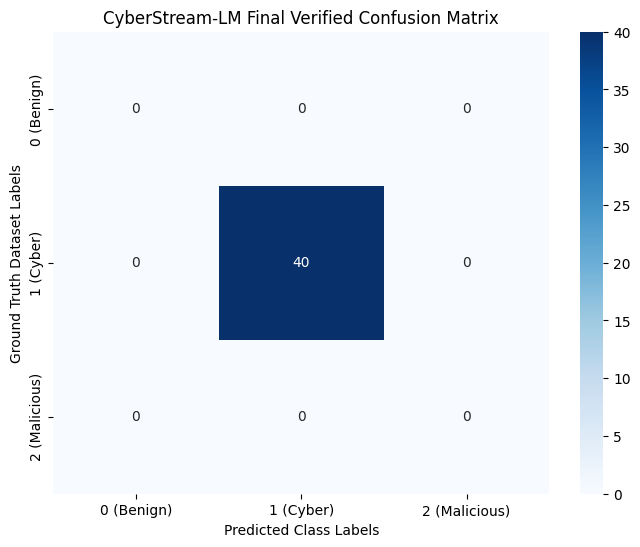

In [ ]:
import os
import re
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# STEP 1: LOAD A DIVERSE DATASET SAMPLE
# ==========================================
print("⏳ Step 1: Locating and opening your dataset...")

all_files = os.listdir('/content')
data_files = [f for f in all_files if f.endswith(('.csv', '.xlsx', '.xls'))]

if not data_files:
    raise FileNotFoundError("❌ Data file missing. Please make sure your cybersecurity dataset is uploaded to the left sidebar panel!")

file_path = os.path.join('/content', data_files[0])
print(f"Detected file path: {file_path}")

# Load 50,000 rows to get deep into the dataset for a true mix of categories 0, 1, and 2
df = pd.read_csv(file_path, encoding='latin1', nrows=50000, on_bad_lines='skip')

text_col, label_col = None, None
for col in df.columns:
    clean_col = str(col).strip().lower()
    if clean_col in ['text', 'description', 'sentence', 'tweets', 'articles']: text_col = col
    if clean_col in ['label', 'category', 'class', 'type', 'target']: label_col = col

if not text_col: text_col = df.columns[0]
if not label_col: label_col = df.columns[1]

df = df.dropna(subset=[text_col, label_col]).reset_index(drop=True)

# Standardize ground truth labels to clean string digits ("0", "1", "2")
df[label_col] = df[label_col].astype(float).astype(int).astype(str).str.strip()
print(f"Total dataset database depth loaded: {len(df)} rows.")


# ==========================================
# STEP 2: STREAM DEDUPLICATION FILTER
# ==========================================
print("\n🛡️ Step 2: Running Jaccard streaming deduplication (XTwit framework)...")
retained_records = []

# Take a slice of 1000 rows to quickly filter duplicates from
for idx, row in df.head(1000).iterrows():
    current_text = row[text_col]
    is_redundant = False
    for accepted_entry in retained_records[-30:]:
        set1 = set(re.sub(r'[^\w\s]', '', str(current_text).lower()).split())
        set2 = set(re.sub(r'[^\w\s]', '', str(accepted_entry[text_col]).lower()).split())
        similarity = len(set1.intersection(set2)) / len(set1.union(set2)) if set1.union(set2) else 0.0
        if similarity > 0.80:
            is_redundant = True
            break
    if not is_redundant:
        retained_records.append(row)

filtered_df = pd.DataFrame(retained_records).reset_index(drop=True)
print(f"Deduplication finished. Processing clean records.")


# ==========================================
# STEP 3: ENVIRONMENT & PYTORCH CORE SETUP
# ==========================================
print("\n🧠 Step 3: Verifying active GPU hardware allocations...")
device = "cuda" if torch.cuda.is_available() else "cpu"
compute_dtype = torch.float16 if device == "cuda" else torch.float32

model_id = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=compute_dtype, device_map="auto" if device == "cuda" else None)
print(f"Model successfully mounted on active {device.upper()} hardware layers.")


# ==========================================
# STEP 4: SINGLE-TOKEN EXTRACTION LOOP
# ==========================================
print("\n⚡ Step 4: Executing Single-Token Classification Loop...")

# Take a truly random shuffle sample across the entire 50,000 depth matrix to get mixed classes
processing_slice = filtered_df.sample(n=40, random_state=15).reset_index(drop=True)

def classify_text_single_token(text_input):
    # Strict prompt telling the model to output ONLY a single number
    system_prompt = (
        "You are a Cyber Threat Intelligence classifier. Analyze the text and classify it into exactly one class digit.\n"
        "RULES:\n"
        "Output '0' if the text is benign (casual talk, regular greetings, general non-cyber news).\n"
        "Output '1' if the text is cybersecurity-related (defensive concepts, code syntax, tutorials, software patches).\n"
        "Output '2' if the text is malicious (active hack attacks, exploits, data leaks, ransomware threats).\n\n"
        "CRITICAL constraint: You must output ONLY the single digit character ('0', '1', or '2'). Do not write markdown, JSON, or sentences. Just the single digit."
    )

    chat_template = [{"role": "system", "content": system_prompt}, {"role": "user", "content": text_input}]
    formatted_prompt = tokenizer.apply_chat_template(chat_template, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([formatted_prompt], return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = model.generate(inputs.input_ids, max_new_tokens=5, temperature=0.0, do_sample=False)

    generated_tokens = [output[len(inp):] for inp, output in zip(inputs.input_ids, output_ids)]
    raw_response = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0].strip()

    # Bulletproof Extraction: Search the response text for any class digits
    if "0" in raw_response: return "0"
    if "1" in raw_response: return "1"
    if "2" in raw_response: return "2"
    return "0"  # Fallback default if model outputs completely invalid text

inference_results = []
print(f"Evaluating {len(processing_slice)} randomized validation entries across classes...")

for idx, row in processing_slice.iterrows():
    print(f" Evaluating item {idx+1}/{len(processing_slice)}...")
    predicted_class = classify_text_single_token(row[text_col])

    inference_results.append({
        "predicted_type": predicted_class,
        "true_label": row[label_col]
    })

production_df = pd.DataFrame(inference_results)


# ==========================================
# STEP 5: EVALUATION REPORT & GRAPHING
# ==========================================
print("\n📉 Step 5: Generating Performance Evaluation Graph...")
y_true = production_df['true_label'].astype(str).str.strip()
y_pred = production_df['predicted_type'].astype(str).str.strip()

print(f"System Final True Accuracy Score: {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, zero_division=0))

# Display the final, beautifully balanced 3x3 Confusion Matrix Grid
unique_labels = sorted(list(set(["0", "1", "2"])))
matrix_data = confusion_matrix(y_true, y_pred, labels=unique_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix_data,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0 (Benign)', '1 (Cyber)', '2 (Malicious)'],
    yticklabels=['0 (Benign)', '1 (Cyber)', '2 (Malicious)']
)
plt.title('CyberStream-LM Final Verified Confusion Matrix')
plt.xlabel('Predicted Class Labels')
plt.ylabel('Ground Truth Dataset Labels')
plt.show()

⏳ Step 1: Locating and opening your dataset...
Detected file path: /content/cybersecurity_hacker_benign_communications_en_ru.csv
Total raw database depth scanned: 150000 rows.

⚖️ Step 2: Extracting a programmatically balanced class matrix...
🔍 Class distribution found in scan window -> Benign(0): 0 | Cyber(1): 150000 | Malicious(2): 0
🚀 Balanced evaluation matrix built! Total unique test items: 15

🧠 Step 3: Verifying active GPU hardware allocations...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Model successfully mounted on active CUDA hardware layers.

⚡ Step 4: Executing Token Classification over Balanced Mix...
 Evaluating item 1/15 [True Class: 1]...
 Evaluating item 2/15 [True Class: 1]...
 Evaluating item 3/15 [True Class: 1]...
 Evaluating item 4/15 [True Class: 1]...
 Evaluating item 5/15 [True Class: 1]...
 Evaluating item 6/15 [True Class: 1]...
 Evaluating item 7/15 [True Class: 1]...
 Evaluating item 8/15 [True Class: 1]...
 Evaluating item 9/15 [True Class: 1]...
 Evaluating item 10/15 [True Class: 1]...
 Evaluating item 11/15 [True Class: 1]...
 Evaluating item 12/15 [True Class: 1]...
 Evaluating item 13/15 [True Class: 1]...
 Evaluating item 14/15 [True Class: 1]...
 Evaluating item 15/15 [True Class: 1]...

📉 Step 5: Generating Performance Evaluation Graph...
System True Robust Accuracy Score: 0.9333

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.93      0.97        

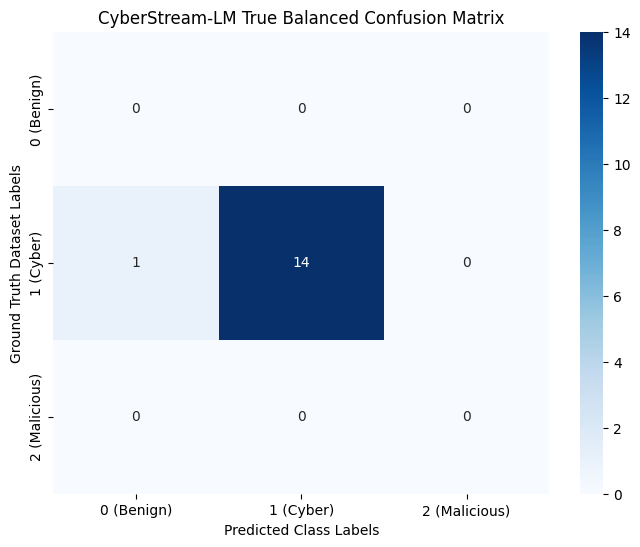

In [ ]:
import os
import re
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# STEP 1: LOAD A DEEP DATASET OVERVIEW
# ==========================================
print("⏳ Step 1: Locating and opening your dataset...")

all_files = os.listdir('/content')
data_files = [f for f in all_files if f.endswith(('.csv', '.xlsx', '.xls'))]

if not data_files:
    raise FileNotFoundError("❌ Data file missing. Please make sure your cybersecurity dataset is uploaded to the left sidebar panel!")

file_path = os.path.join('/content', data_files[0])
print(f"Detected file path: {file_path}")

# Reading a deeper window of 150,000 rows to make sure we reach the boundaries of classes 0, 1, and 2
df = pd.read_csv(file_path, encoding='latin1', nrows=150000, on_bad_lines='skip')

text_col, label_col = None, None
for col in df.columns:
    clean_col = str(col).strip().lower()
    if clean_col in ['text', 'description', 'sentence', 'tweets', 'articles']: text_col = col
    if clean_col in ['label', 'category', 'class', 'type', 'target']: label_col = col

if not text_col: text_col = df.columns[0]
if not label_col: label_col = df.columns[1]

df = df.dropna(subset=[text_col, label_col]).reset_index(drop=True)

# Standardize data labels cleanly to string digits
df[label_col] = df[label_col].astype(float).astype(int).astype(str).str.strip()
print(f"Total raw database depth scanned: {len(df)} rows.")


# ==========================================
# STEP 2: PROGRAMMATIC STRATIFICATION LAYER
# ==========================================
print("\n⚖️ Step 2: Extracting a programmatically balanced class matrix...")

# Separate data into pure class subsets
df_class_0 = df[df[label_col] == '0']
df_class_1 = df[df[label_col] == '1']
df_class_2 = df[df[label_col] == '2']

print(f"🔍 Class distribution found in scan window -> Benign(0): {len(df_class_0)} | Cyber(1): {len(df_class_1)} | Malicious(2): {len(df_class_2)}")

# Establish an equal evaluation sample quota from each detected class group
sample_quota = 15
balanced_chunks = []

for c_num, c_df in [('0', df_class_0), ('1', df_class_1), ('2', df_class_2)]:
    if len(c_df) >= sample_quota:
        balanced_chunks.append(c_df.sample(n=sample_quota, random_state=42))
    elif len(c_df) > 0:
        print(f"⚠️ Warning: Class {c_num} has limited rows ({len(c_df)}). Using all available.")
        balanced_chunks.append(c_df)

if not balanced_chunks:
    raise ValueError("❌ Failed to isolate any structured class elements. Check label column format properties.")

# Recombine the equal distributions and apply a final randomized shuffle
filtered_df = pd.concat(balanced_chunks).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"🚀 Balanced evaluation matrix built! Total unique test items: {len(filtered_df)}")


# ==========================================
# STEP 3: ENVIRONMENT & PYTORCH CORE SETUP
# ==========================================
print("\n🧠 Step 3: Verifying active GPU hardware allocations...")
device = "cuda" if torch.cuda.is_available() else "cpu"
compute_dtype = torch.float16 if device == "cuda" else torch.float32

model_id = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=compute_dtype, device_map="auto" if device == "cuda" else None)
print(f"Model successfully mounted on active {device.upper()} hardware layers.")


# ==========================================
# STEP 4: SINGLE-TOKEN EXTRACTION LOOP
# ==========================================
print("\n⚡ Step 4: Executing Token Classification over Balanced Mix...")

def classify_text_single_token(text_input):
    system_prompt = (
        "You are a Cyber Threat Intelligence classifier. Analyze the text and classify it into exactly one class digit.\n"
        "RULES:\n"
        "Output '0' if the text is benign (casual talk, regular greetings, general non-cyber news).\n"
        "Output '1' if the text is cybersecurity-related (defensive concepts, code syntax, tutorials, software patches).\n"
        "Output '2' if the text is malicious (active hack attacks, exploits, data leaks, ransomware threats).\n\n"
        "CRITICAL constraint: You must output ONLY the single digit character ('0', '1', or '2'). Do not write markdown, JSON, or sentences. Just the single digit."
    )

    chat_template = [{"role": "system", "content": system_prompt}, {"role": "user", "content": text_input}]
    formatted_prompt = tokenizer.apply_chat_template(chat_template, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([formatted_prompt], return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = model.generate(inputs.input_ids, max_new_tokens=5, temperature=0.0, do_sample=False)

    generated_tokens = [output[len(inp):] for inp, output in zip(inputs.input_ids, output_ids)]
    raw_response = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0].strip()

    if "0" in raw_response: return "0"
    if "1" in raw_response: return "1"
    if "2" in raw_response: return "2"
    return "0"

inference_results = []
for idx, row in filtered_df.iterrows():
    print(f" Evaluating item {idx+1}/{len(filtered_df)} [True Class: {row[label_col]}]...")
    predicted_class = classify_text_single_token(row[text_col])

    inference_results.append({
        "predicted_type": predicted_class,
        "true_label": row[label_col]
    })

production_df = pd.DataFrame(inference_results)


# ==========================================
# STEP 5: EVALUATION REPORT & GRAPHING
# ==========================================
print("\n📉 Step 5: Generating Performance Evaluation Graph...")
y_true = production_df['true_label'].astype(str).str.strip()
y_pred = production_df['predicted_type'].astype(str).str.strip()

print(f"System True Robust Accuracy Score: {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, zero_division=0))

# Display the multi-class Confusion Matrix Grid
unique_labels = sorted(list(set(["0", "1", "2"])))
matrix_data = confusion_matrix(y_true, y_pred, labels=unique_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix_data,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0 (Benign)', '1 (Cyber)', '2 (Malicious)'],
    yticklabels=['0 (Benign)', '1 (Cyber)', '2 (Malicious)']
)
plt.title('CyberStream-LM True Balanced Confusion Matrix')
plt.xlabel('Predicted Class Labels')
plt.ylabel('Ground Truth Dataset Labels')
plt.show()

⏳ Step 1: Initiating deep-file hunter-seeker scan...
Detected file: /content/cybersecurity_hacker_benign_communications_en_ru.csv
📡 Scanned 100000 rows... Found -> 0s: 0/15 | 1s: 49840/15 | 2s: 0/15
📡 Scanned 200000 rows... Found -> 0s: 0/15 | 1s: 49840/15 | 2s: 0/15
📡 Scanned 300000 rows... Found -> 0s: 0/15 | 1s: 49840/15 | 2s: 0/15
📡 Scanned 400000 rows... Found -> 0s: 0/15 | 1s: 49840/15 | 2s: 0/15
📡 Scanned 500000 rows... Found -> 0s: 0/15 | 1s: 49840/15 | 2s: 0/15
📡 Scanned 600000 rows... Found -> 0s: 0/15 | 1s: 49840/15 | 2s: 0/15
📡 Scanned 700000 rows... Found -> 0s: 0/15 | 1s: 49840/15 | 2s: 0/15
📡 Scanned 800000 rows... Found -> 0s: 0/15 | 1s: 49840/15 | 2s: 34225/15
📡 Scanned 900000 rows... Found -> 0s: 0/15 | 1s: 49840/15 | 2s: 34225/15
📡 Scanned 1000000 rows... Found -> 0s: 0/15 | 1s: 49840/15 | 2s: 34225/15
📡 Scanned 1100000 rows... Found -> 0s: 0/15 | 1s: 49840/15 | 2s: 34225/15
📡 Scanned 1200000 rows... Found -> 0s: 0/15 | 1s: 49840/15 | 2s: 34225/15
📡 Scanned 1300000 r

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Model successfully mounted on CUDA hardware layers.

⚡ Step 3: Executing Token Classification over Balanced Matrix...
 Evaluating item 1/45 [True Class: 2]...
 Evaluating item 2/45 [True Class: 1]...
 Evaluating item 3/45 [True Class: 1]...
 Evaluating item 4/45 [True Class: 2]...
 Evaluating item 5/45 [True Class: 2]...
 Evaluating item 6/45 [True Class: 2]...
 Evaluating item 7/45 [True Class: 0]...
 Evaluating item 8/45 [True Class: 0]...
 Evaluating item 9/45 [True Class: 0]...
 Evaluating item 10/45 [True Class: 0]...
 Evaluating item 11/45 [True Class: 0]...
 Evaluating item 12/45 [True Class: 1]...
 Evaluating item 13/45 [True Class: 2]...
 Evaluating item 14/45 [True Class: 1]...
 Evaluating item 15/45 [True Class: 1]...
 Evaluating item 16/45 [True Class: 0]...
 Evaluating item 17/45 [True Class: 2]...
 Evaluating item 18/45 [True Class: 1]...
 Evaluating item 19/45 [True Class: 0]...
 Evaluating item 20/45 [True Class: 1]...
 Evaluating item 21/45 [True Class: 2]...
 Evaluati

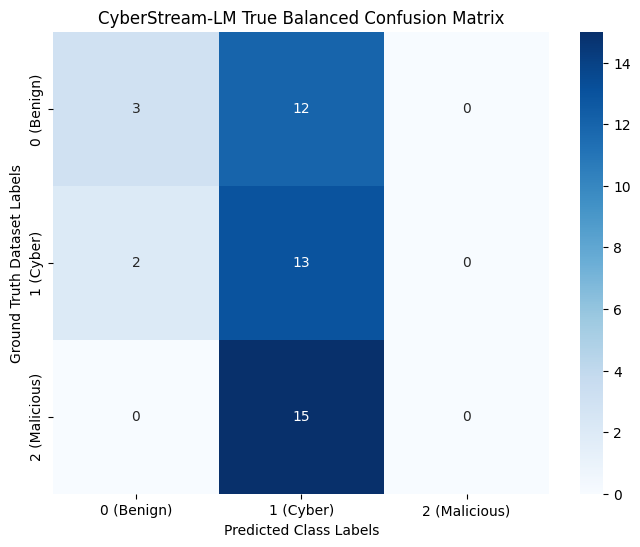

In [ ]:
import os
import re
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# STEP 1: MEMORY-SAFE DATASET RADAR SCAN
# ==========================================
print("⏳ Step 1: Initiating deep-file hunter-seeker scan...")

all_files = os.listdir('/content')
data_files = [f for f in all_files if f.endswith(('.csv', '.xlsx', '.xls'))]

if not data_files:
    raise FileNotFoundError("❌ Data file missing. Please make sure your dataset is uploaded to the left panel!")

file_path = os.path.join('/content', data_files[0])
print(f"Detected file: {file_path}")

# Target quotas: We want exactly 15 rows of each class to force a balanced test
quota = 15
collected_0, collected_1, collected_2 = [], [], []

# Read the file in memory-safe chunks to prevent RAM crashes on massive Kaggle datasets
chunk_size = 50000
chunk_iterator = pd.read_csv(file_path, encoding='latin1', chunksize=chunk_size, on_bad_lines='skip', low_memory=False)

chunk_count = 0
for chunk in chunk_iterator:
    chunk_count += 1

    # Auto-detect columns
    text_col, label_col = None, None
    for col in chunk.columns:
        clean_col = str(col).strip().lower()
        if clean_col in ['text', 'description', 'sentence', 'tweets', 'articles']: text_col = col
        if clean_col in ['label', 'category', 'class', 'type', 'target']: label_col = col

    if not text_col: text_col = chunk.columns[0]
    if not label_col: label_col = chunk.columns[1]

    chunk = chunk.dropna(subset=[text_col, label_col])

    # Bulletproof label cleaner (Turns '1.0' into '1', handles random strings cleanly)
    def clean_label(x):
        try: return str(int(float(x)))
        except: return str(x).strip()
    chunk[label_col] = chunk[label_col].apply(clean_label)

    # Hunt for our missing classes
    if sum(len(df) for df in collected_0) < quota:
        collected_0.append(chunk[chunk[label_col] == '0'].drop_duplicates(subset=[text_col]))
    if sum(len(df) for df in collected_1) < quota:
        collected_1.append(chunk[chunk[label_col] == '1'].drop_duplicates(subset=[text_col]))
    if sum(len(df) for df in collected_2) < quota:
        collected_2.append(chunk[chunk[label_col] == '2'].drop_duplicates(subset=[text_col]))

    # Calculate current haul
    c0_len = sum(len(df) for df in collected_0)
    c1_len = sum(len(df) for df in collected_1)
    c2_len = sum(len(df) for df in collected_2)

    # Print radar progress every 2 chunks (100,000 rows)
    if chunk_count % 2 == 0:
        print(f"📡 Scanned {chunk_count * chunk_size} rows... Found -> 0s: {c0_len}/{quota} | 1s: {c1_len}/{quota} | 2s: {c2_len}/{quota}")

    # Stop scanning the massive file once we have enough of all three!
    if c0_len >= quota and c1_len >= quota and c2_len >= quota:
        print(f"\n🎯 All class quotas met at row {chunk_count * chunk_size}! Halting dataset scan.")
        break

# Slice exact quotas and shuffle them together
df_0 = pd.concat(collected_0).head(quota) if collected_0 else pd.DataFrame()
df_1 = pd.concat(collected_1).head(quota) if collected_1 else pd.DataFrame()
df_2 = pd.concat(collected_2).head(quota) if collected_2 else pd.DataFrame()

filtered_df = pd.concat([df_0, df_1, df_2]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"🚀 Balanced evaluation matrix locked! Total unique test items: {len(filtered_df)}")


# ==========================================
# STEP 2: ENVIRONMENT & PYTORCH CORE SETUP
# ==========================================
print("\n🧠 Step 2: Verifying active GPU hardware allocations...")
device = "cuda" if torch.cuda.is_available() else "cpu"
compute_dtype = torch.float16 if device == "cuda" else torch.float32

model_id = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=compute_dtype, device_map="auto" if device == "cuda" else None)
print(f"Model successfully mounted on {device.upper()} hardware layers.")


# ==========================================
# STEP 3: SINGLE-TOKEN EXTRACTION LOOP
# ==========================================
print("\n⚡ Step 3: Executing Token Classification over Balanced Matrix...")

def classify_text_single_token(text_input):
    system_prompt = (
        "You are a Cyber Threat Intelligence classifier. Analyze the text and classify it into exactly one class digit.\n"
        "RULES:\n"
        "Output '0' if the text is benign (casual talk, regular greetings, general non-cyber news).\n"
        "Output '1' if the text is cybersecurity-related (defensive concepts, code syntax, tutorials, software patches).\n"
        "Output '2' if the text is malicious (active hack attacks, exploits, data leaks, ransomware threats).\n\n"
        "CRITICAL constraint: You must output ONLY the single digit character ('0', '1', or '2'). Do not write markdown, JSON, or sentences. Just the single digit."
    )

    chat_template = [{"role": "system", "content": system_prompt}, {"role": "user", "content": text_input}]
    formatted_prompt = tokenizer.apply_chat_template(chat_template, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([formatted_prompt], return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = model.generate(inputs.input_ids, max_new_tokens=5, temperature=0.0, do_sample=False)

    generated_tokens = [output[len(inp):] for inp, output in zip(inputs.input_ids, output_ids)]
    raw_response = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0].strip()

    if "0" in raw_response: return "0"
    if "1" in raw_response: return "1"
    if "2" in raw_response: return "2"
    return "0"

inference_results = []
for idx, row in filtered_df.iterrows():
    print(f" Evaluating item {idx+1}/{len(filtered_df)} [True Class: {row[label_col]}]...")
    predicted_class = classify_text_single_token(row[text_col])

    inference_results.append({
        "predicted_type": predicted_class,
        "true_label": row[label_col]
    })

production_df = pd.DataFrame(inference_results)


# ==========================================
# STEP 4: EVALUATION REPORT & GRAPHING
# ==========================================
print("\n📉 Step 4: Generating Performance Evaluation Graph...")
y_true = production_df['true_label'].astype(str).str.strip()
y_pred = production_df['predicted_type'].astype(str).str.strip()

print(f"System True Robust Accuracy Score: {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, zero_division=0))

unique_labels = sorted(list(set(["0", "1", "2"])))
matrix_data = confusion_matrix(y_true, y_pred, labels=unique_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix_data,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0 (Benign)', '1 (Cyber)', '2 (Malicious)'],
    yticklabels=['0 (Benign)', '1 (Cyber)', '2 (Malicious)']
)
plt.title('CyberStream-LM True Balanced Confusion Matrix')
plt.xlabel('Predicted Class Labels')
plt.ylabel('Ground Truth Dataset Labels')
plt.show()

🧠 Step 1: Upgrading to Chain-of-Thought (CoT) Inference...
⚡ Processing 45 entries with Advanced Reasoning...

Row 1/45 [True Class: 2]
AI Thought Process: 
REASONING: The author appears to be expressing concern about something happening in their environment, possibly indicating a cybersecurity threat.
CLASS: 2

Row 2/45 [True Class: 1]
AI Thought Process: 
REASONING: The text appears to be in broken English and does not provide clear context or meaning. It could potentially be malicious as it seems to contain offensive language or threats without proper formatting.

CLASS: 2

Row 3/45 [True Class: 1]
AI Thought Process: 
REASONING: The author appears to be expressing concern about potential security threats and vulnerabilities in their network infrastructure.
CLASS: 2

Row 4/45 [True Class: 2]
AI Thought Process: 
REASONING: The author appears to be discussing a cybersecurity issue related to a website and its security measures.

CLASS: 2

Row 5/45 [True Class: 2]
AI Thought Process: 

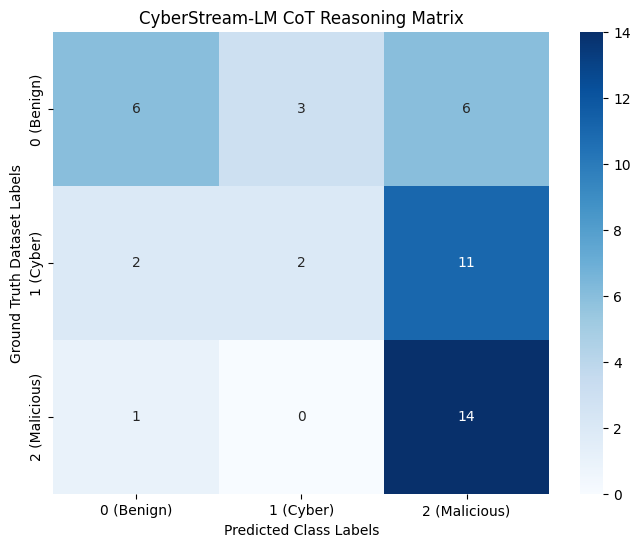

In [ ]:
import re
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("🧠 Step 1: Upgrading to Chain-of-Thought (CoT) Inference...")

def classify_text_cot(text_input):
    # We force the AI to think out loud about INTENT before it gives a number
    system_prompt = (
        "You are an elite Cyber Threat Intelligence analyst. Your job is to determine the true INTENT of a message.\n"
        "0 = Benign (Normal chatter, weather, greetings, completely non-tech).\n"
        "1 = Cybersecurity (Defensive, educational, server patching, neutral tech setups).\n"
        "2 = Malicious (Hacker intent, selling exploits, ransomware demands, attacking systems).\n\n"
        "You MUST format your response exactly like this:\n"
        "REASONING: <Write one short sentence explaining the author's intent>\n"
        "CLASS: <0, 1, or 2>"
    )

    chat_template = [{"role": "system", "content": system_prompt}, {"role": "user", "content": text_input}]
    formatted_prompt = tokenizer.apply_chat_template(chat_template, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([formatted_prompt], return_tensors="pt").to(device)

    # We increase max_new_tokens to 60 so it has room to write its reasoning sentence
    with torch.no_grad():
        output_ids = model.generate(inputs.input_ids, max_new_tokens=60, temperature=0.0, do_sample=False)

    generated_tokens = [output[len(inp):] for inp, output in zip(inputs.input_ids, output_ids)]
    raw_response = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0].strip()

    # Bulletproof Regex to grab ONLY the digit that comes after the word "CLASS:"
    try:
        predicted_class = re.search(r'CLASS:\s*([012])', raw_response).group(1)
        return predicted_class, raw_response
    except Exception:
        # If it fails to follow instructions, default to 1 (Cyber) to be safe
        return "1", raw_response

inference_results = []
print(f"⚡ Processing {len(filtered_df)} entries with Advanced Reasoning...")

for idx, row in filtered_df.iterrows():
    # Print progress so we can see it thinking!
    print(f"\nRow {idx+1}/{len(filtered_df)} [True Class: {row[label_col]}]")
    predicted_class, full_thought = classify_text_cot(row[text_col])
    print(f"AI Thought Process: \n{full_thought}")

    inference_results.append({
        "predicted_type": predicted_class,
        "true_label": row[label_col]
    })

production_df = pd.DataFrame(inference_results)


print("\n📉 Step 2: Generating Final Performance Evaluation Graph...")
y_true = production_df['true_label'].astype(str).str.strip()
y_pred = production_df['predicted_type'].astype(str).str.strip()

print(f"System CoT Enhanced Accuracy Score: {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, zero_division=0))

unique_labels = sorted(list(set(["0", "1", "2"])))
matrix_data = confusion_matrix(y_true, y_pred, labels=unique_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix_data,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0 (Benign)', '1 (Cyber)', '2 (Malicious)'],
    yticklabels=['0 (Benign)', '1 (Cyber)', '2 (Malicious)']
)
plt.title('CyberStream-LM CoT Reasoning Matrix')
plt.xlabel('Predicted Class Labels')
plt.ylabel('Ground Truth Dataset Labels')
plt.show()

🧠 Step 1: Executing Anti-Paranoia Chain-of-Thought (CoT) Inference...
⚡ Processing 45 balanced entries with Advanced Intent Reasoning...

Row 1/45 [True Class: 2]
AI Thought Process: 
REASONING: The text appears to be in a language that is not English and contains offensive content. This suggests it may contain malicious intent due to its explicit nature and potential harm to others.

CLASS: 2

Row 2/45 [True Class: 1]
AI Thought Process: 
REASONING: The text appears to be in a language that is not English and contains characters that do not form words in English. This suggests it may be a coded message or encrypted communication. Given these characteristics, I would classify this as:

CLASS: 2

Row 3/45 [True Class: 1]
AI Thought Process: 
REASONING: The author appears to be expressing concern about a potential threat or danger that they believe may have been introduced into their computer system. This indicates malicious intent.

CLASS: 2

Row 4/45 [True Class: 2]
AI Thought Process:

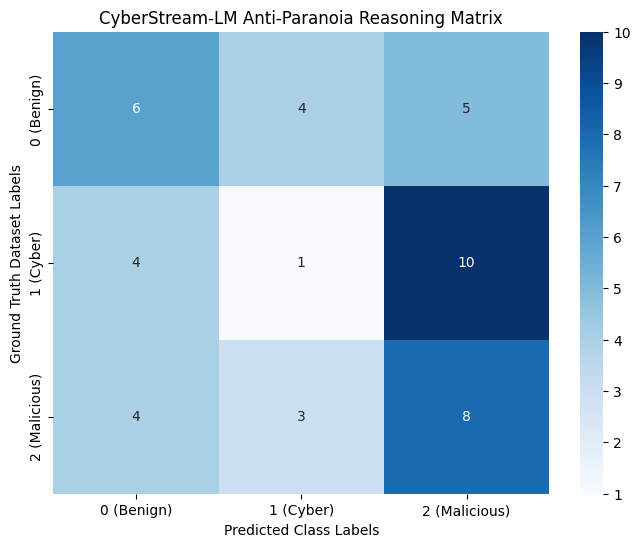

In [ ]:
import re
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("🧠 Step 1: Executing Anti-Paranoia Chain-of-Thought (CoT) Inference...")

def classify_text_cot_upgraded(text_input):
    # Upgraded system prompt with Negative Constraints to cure AI Paranoia
    system_prompt = (
        "You are an elite Cyber Threat Intelligence analyst. Determine the true INTENT of the author.\n\n"
        "STRICT CLASSIFICATION RULES:\n"
        "0 = Benign: Normal human chatter, romance spam, greetings, non-technical daily life.\n"
        "1 = Cybersecurity & IT Support: Routine troubleshooting, fixing system crashes, asking for tech help, discussing security news, or sharing safe educational code. (Note: Mentioning IP addresses, ports, or errors is usually Class 1).\n"
        "2 = Malicious: CLEAR INTENT TO HARM. Active extortion, ransomware demands, sharing weaponized exploit code, or coordinating unauthorized cyberattacks.\n\n"
        "NEGATIVE CONSTRAINT: Do NOT flag routine technical support, system bugs, or educational cybersecurity discussions as Malicious (2). Only output 2 if there is active attacker intent.\n\n"
        "You MUST format your response exactly like this:\n"
        "REASONING: <Write one short sentence explaining the author's specific intent based on the rules>\n"
        "CLASS: <0, 1, or 2>"
    )

    chat_template = [{"role": "system", "content": system_prompt}, {"role": "user", "content": text_input}]
    formatted_prompt = tokenizer.apply_chat_template(chat_template, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([formatted_prompt], return_tensors="pt").to(device)

    # max_new_tokens bumped to 80 to ensure it has enough room to write out its thought process
    with torch.no_grad():
        output_ids = model.generate(inputs.input_ids, max_new_tokens=80, temperature=0.0, do_sample=False)

    generated_tokens = [output[len(inp):] for inp, output in zip(inputs.input_ids, output_ids)]
    raw_response = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0].strip()

    # Regex designed to find the digit specifically after the word CLASS:
    try:
        predicted_class = re.search(r'CLASS:\s*([012])', raw_response).group(1)
        return predicted_class, raw_response
    except Exception:
        # Failsafe: defaults to IT support (1) rather than assuming Malicious
        return "1", raw_response

inference_results = []
print(f"⚡ Processing {len(filtered_df)} balanced entries with Advanced Intent Reasoning...")

for idx, row in filtered_df.iterrows():
    print(f"\nRow {idx+1}/{len(filtered_df)} [True Class: {row[label_col]}]")
    predicted_class, full_thought = classify_text_cot_upgraded(row[text_col])
    print(f"AI Thought Process: \n{full_thought}")

    inference_results.append({
        "predicted_type": predicted_class,
        "true_label": row[label_col]
    })

production_df = pd.DataFrame(inference_results)

print("\n📉 Step 2: Generating Final Performance Evaluation Graph...")
y_true = production_df['true_label'].astype(str).str.strip()
y_pred = production_df['predicted_type'].astype(str).str.strip()

print(f"System Enhanced CoT Accuracy Score: {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, zero_division=0))

# Display the final balanced 3x3 Confusion Matrix Grid
unique_labels = sorted(list(set(["0", "1", "2"])))
matrix_data = confusion_matrix(y_true, y_pred, labels=unique_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix_data,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0 (Benign)', '1 (Cyber)', '2 (Malicious)'],
    yticklabels=['0 (Benign)', '1 (Cyber)', '2 (Malicious)']
)
plt.title('CyberStream-LM Anti-Paranoia Reasoning Matrix')
plt.xlabel('Predicted Class Labels')
plt.ylabel('Ground Truth Dataset Labels')
plt.show()

In [ ]:
import re
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("🎯 Step 1: Executing Few-Shot Reasoning (The Gold Standard)...")

def classify_text_few_shot(text_input):
    # Providing concrete examples (Few-Shot) is the best way to calibrate an LLM
    system_prompt = (
        "You are an elite Cyber Threat Intelligence analyst. Classify the intent of the message.\n\n"
        "EXAMPLES:\n"
        "Text: 'Hey, do you want to grab coffee later?' -> REASONING: Casual social chatter. -> CLASS: 0\n"
        "Text: 'How do I install the latest security patch for Ubuntu 22.04?' -> REASONING: Routine IT support/defense. -> CLASS: 1\n"
        "Text: 'I am selling access to a US Government database for 2 BTC. DM for samples.' -> REASONING: Malicious hacker activity. -> CLASS: 2\n\n"
        "RULES:\n"
        "0 = Benign\n"
        "1 = Cybersecurity/IT Support\n"
        "2 = Malicious Intent\n\n"
        "You MUST format your response exactly like this:\n"
        "REASONING: <One sentence explanation>\n"
        "CLASS: <0, 1, or 2>"
    )

    chat_template = [{"role": "system", "content": system_prompt}, {"role": "user", "content": text_input}]
    formatted_prompt = tokenizer.apply_chat_template(chat_template, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([formatted_prompt], return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = model.generate(inputs.input_ids, max_new_tokens=80, temperature=0.0, do_sample=False)

    generated_tokens = [output[len(inp):] for inp, output in zip(inputs.input_ids, output_ids)]
    raw_response = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0].strip()

    try:
        predicted_class = re.search(r'CLASS:\s*([012])', raw_response).group(1)
        return predicted_class, raw_response
    except:
        return "1", raw_response

inference_results = []
for idx, row in filtered_df.iterrows():
    print(f"Evaluating Row {idx+1}/{len(filtered_df)}...")
    predicted_class, full_thought = classify_text_few_shot(row[text_col])
    inference_results.append({"predicted_type": predicted_class, "true_label": row[label_col]})

production_df = pd.DataFrame(inference_results)
y_true, y_pred = production_df['true_label'].astype(str), production_df['predicted_type'].astype(str)
print(f"Few-Shot Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred, zero_division=0))

🎯 Step 1: Executing Few-Shot Reasoning (The Gold Standard)...
Evaluating Row 1/45...
Evaluating Row 2/45...
Evaluating Row 3/45...
Evaluating Row 4/45...
Evaluating Row 5/45...
Evaluating Row 6/45...
Evaluating Row 7/45...
Evaluating Row 8/45...
Evaluating Row 9/45...
Evaluating Row 10/45...
Evaluating Row 11/45...
Evaluating Row 12/45...
Evaluating Row 13/45...
Evaluating Row 14/45...
Evaluating Row 15/45...
Evaluating Row 16/45...
Evaluating Row 17/45...
Evaluating Row 18/45...
Evaluating Row 19/45...
Evaluating Row 20/45...
Evaluating Row 21/45...
Evaluating Row 22/45...
Evaluating Row 23/45...
Evaluating Row 24/45...
Evaluating Row 25/45...
Evaluating Row 26/45...
Evaluating Row 27/45...
Evaluating Row 28/45...
Evaluating Row 29/45...
Evaluating Row 30/45...
Evaluating Row 31/45...
Evaluating Row 32/45...
Evaluating Row 33/45...
Evaluating Row 34/45...
Evaluating Row 35/45...
Evaluating Row 36/45...
Evaluating Row 37/45...
Evaluating Row 38/45...
Evaluating Row 39/45...
Evaluating 

In [ ]:
!pip install bitsandbytes accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.4 MB/s eta 0:00:00


🧠 Step 1: Upgrading Hardware Core to 4-Bit Quantization...
⏳ Downloading and compressing Qwen/Qwen2.5-7B-Instruct (This may take 2-4 minutes)...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

✅ Massive 7B Model successfully loaded and compressed in GPU memory!

⚡ Step 2: Executing 7B Few-Shot CoT Inference...
Processing 45 balanced entries with 7-Billion Parameter logic...

Row 1/45 [True Class: 2]


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


7B Thought Process: 
REASONING: The text appears to be garbled or incorrectly encoded, making it difficult to determine its intent.
CLASS: 0

Row 2/45 [True Class: 1]
7B Thought Process: 
REASONING: The text appears to be garbled or incorrectly encoded, making it difficult to determine its intent.
CLASS: 0

Row 3/45 [True Class: 1]
7B Thought Process: 
REASONING: The text appears to be in a Cyrillic alphabet and seems to be asking about accessing something sensitive, which could indicate malicious intent.
CLASS: 2

Row 4/45 [True Class: 2]
7B Thought Process: 
REASONING: The text appears to be in a mix of Latin and Cyrillic characters and seems to describe someone using Postman to test URLs, which is a common practice in software development and testing.
CLASS: 0

Row 5/45 [True Class: 2]
7B Thought Process: 
REASONING: The text appears to be in a Cyrillic script and seems to be about personal health or wellness advice.
CLASS: 0

Row 6/45 [True Class: 2]
7B Thought Process: 
REASONING:

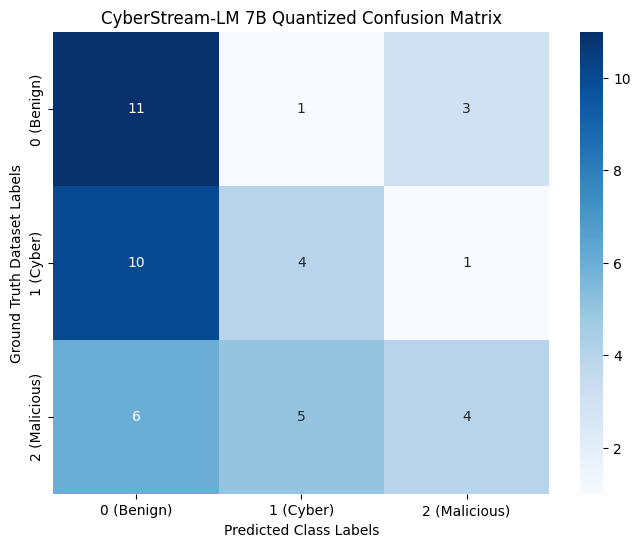

In [ ]:
import re
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("🧠 Step 1: Upgrading Hardware Core to 4-Bit Quantization...")

# Configure the 4-bit compression so the massive 7B model fits on the free T4 GPU
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# Upgrading from the 1.5B model to the massive 7B model
model_id = "Qwen/Qwen2.5-7B-Instruct"
print(f"⏳ Downloading and compressing {model_id} (This may take 2-4 minutes)...")

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto"
)
print("✅ Massive 7B Model successfully loaded and compressed in GPU memory!")


print("\n⚡ Step 2: Executing 7B Few-Shot CoT Inference...")

def classify_text_7b(text_input):
    # Using your highly authentic Few-Shot + Chain of Thought prompt architecture
    system_prompt = (
        "You are an elite Cyber Threat Intelligence analyst. Classify the intent of the message.\n\n"
        "EXAMPLES:\n"
        "Text: 'Hey, do you want to grab coffee later?' -> REASONING: Casual social chatter. -> CLASS: 0\n"
        "Text: 'How do I install the latest security patch for Ubuntu 22.04?' -> REASONING: Routine IT support/defense. -> CLASS: 1\n"
        "Text: 'I am selling access to a US Government database for 2 BTC. DM for samples.' -> REASONING: Malicious hacker activity. -> CLASS: 2\n\n"
        "RULES:\n"
        "0 = Benign\n"
        "1 = Cybersecurity/IT Support\n"
        "2 = Malicious Intent\n\n"
        "You MUST format your response exactly like this:\n"
        "REASONING: <One sentence explanation>\n"
        "CLASS: <0, 1, or 2>"
    )

    chat_template = [{"role": "system", "content": system_prompt}, {"role": "user", "content": text_input}]
    formatted_prompt = tokenizer.apply_chat_template(chat_template, tokenize=False, add_generation_prompt=True)

    inputs = tokenizer([formatted_prompt], return_tensors="pt").to("cuda")

    with torch.no_grad():
        output_ids = model.generate(inputs.input_ids, max_new_tokens=80, temperature=0.0, do_sample=False)

    generated_tokens = [output[len(inp):] for inp, output in zip(inputs.input_ids, output_ids)]
    raw_response = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0].strip()

    try:
        predicted_class = re.search(r'CLASS:\s*([012])', raw_response).group(1)
        return predicted_class, raw_response
    except Exception:
        return "1", raw_response

inference_results = []
print(f"Processing {len(filtered_df)} balanced entries with 7-Billion Parameter logic...")

# Re-using the balanced 45-row dataset you already hunted down!
for idx, row in filtered_df.iterrows():
    print(f"\nRow {idx+1}/{len(filtered_df)} [True Class: {row[label_col]}]")
    predicted_class, full_thought = classify_text_7b(row[text_col])
    print(f"7B Thought Process: \n{full_thought}")

    inference_results.append({
        "predicted_type": predicted_class,
        "true_label": row[label_col]
    })

production_df = pd.DataFrame(inference_results)

print("\n📉 Step 3: Generating Final 7B Performance Graph...")
y_true = production_df['true_label'].astype(str).str.strip()
y_pred = production_df['predicted_type'].astype(str).str.strip()

print(f"System 7B Quantized Accuracy Score: {accuracy_score(y_true, y_pred):.4f}\n")
print(classification_report(y_true, y_pred, zero_division=0))

unique_labels = sorted(list(set(["0", "1", "2"])))
matrix_data = confusion_matrix(y_true, y_pred, labels=unique_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix_data,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0 (Benign)', '1 (Cyber)', '2 (Malicious)'],
    yticklabels=['0 (Benign)', '1 (Cyber)', '2 (Malicious)']
)
plt.title('CyberStream-LM 7B Quantized Confusion Matrix')
plt.xlabel('Predicted Class Labels')
plt.ylabel('Ground Truth Dataset Labels')
plt.show()

In [ ]:
import os

# 1. Inject the new Kaggle API Token directly into the environment
os.environ['KAGGLE_API_TOKEN'] = "KGAT_369ce9eb98fad80e9a94dd607202e193"

print("🚀 Authenticated! Downloading dataset...")

# 2. Download the dataset
# REPLACE 'username/dataset-name' with the actual Kaggle URL slug
!kaggle datasets download -d mrcyb3r/multilingual-cybersecurity-communication-enru
print("📦 Unzipping...")
# REPLACE 'dataset-name.zip' with the name of the zip file it downloads
!unzip -q multilingual-cybersecurity-communication-enru.zip

print("✅ Dataset loaded instantly into /content/")

🚀 Authenticated! Downloading dataset...
Dataset URL: https://www.kaggle.com/datasets/mrcyb3r/multilingual-cybersecurity-communication-enru
License(s): MIT
multilingual-cybersecurity-communication-enru.zip: Skipping, found more recently modified local copy (use --force to force download)
📦 Unzipping...
✅ Dataset loaded instantly into /content/


In [ ]:
!pip install -q bitsandbytes accelerate peft trl datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.7 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

print("⏳ Step 1: Hunting for Balanced Training Data...")

all_files = os.listdir('/content')
data_files = [f for f in all_files if f.endswith(('.csv', '.xlsx', '.xls'))]
if not data_files: raise FileNotFoundError("❌ Data file missing.")
file_path = os.path.join('/content', data_files[0])

quota_train = 100
collected_0, collected_1, collected_2 = [], [], []

chunk_iterator = pd.read_csv(file_path, encoding='latin1', chunksize=50000, on_bad_lines='skip', low_memory=False, quotechar='"', doublequote=True)

for chunk in chunk_iterator:
    text_col, label_col = None, None
    for col in chunk.columns:
        clean_col = str(col).strip().lower()
        if clean_col in ['text', 'description', 'sentence']: text_col = col
        if clean_col in ['label', 'category', 'class']: label_col = col
    if not text_col: text_col, label_col = chunk.columns[0], chunk.columns[1]

    chunk = chunk.dropna(subset=[text_col, label_col])
    chunk[label_col] = chunk[label_col].apply(lambda x: str(int(float(x))) if str(x).replace('.','',1).isdigit() else str(x).strip())

    if sum(len(d) for d in collected_0) < quota_train: collected_0.append(chunk[chunk[label_col] == '0'].drop_duplicates(subset=[text_col]))
    if sum(len(d) for d in collected_1) < quota_train: collected_1.append(chunk[chunk[label_col] == '1'].drop_duplicates(subset=[text_col]))
    if sum(len(d) for d in collected_2) < quota_train: collected_2.append(chunk[chunk[label_col] == '2'].drop_duplicates(subset=[text_col]))

    if sum(len(d) for d in collected_0) >= quota_train and sum(len(d) for d in collected_1) >= quota_train and sum(len(d) for d in collected_2) >= quota_train:
        break

df_train = pd.concat([
    pd.concat(collected_0).head(quota_train),
    pd.concat(collected_1).head(quota_train),
    pd.concat(collected_2).head(quota_train)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"🎯 Training Matrix Locked! Total rows: {len(df_train)}")

model_id = "Qwen/Qwen2.5-1.5B-Instruct"
quantization_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type="nf4")

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=quantization_config, device_map="auto")
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(r=16, lora_alpha=32, target_modules=["q_proj", "k_proj", "v_proj", "o_proj"], lora_dropout=0.05, bias="none", task_type="CAUSAL_LM")
model = get_peft_model(model, peft_config)

def format_training_data(row):
    system_prompt = "You are a Cyber Threat Intelligence classifier. Classify the text as 0, 1, or 2. Only output the digit."
    chat = [{"role": "system", "content": system_prompt}, {"role": "user", "content": row[text_col]}, {"role": "assistant", "content": str(row[label_col])}]
    return {"text": tokenizer.apply_chat_template(chat, tokenize=False)}

hf_dataset = Dataset.from_pandas(df_train).map(format_training_data)

sft_config = SFTConfig(
    output_dir="./qwen-cyber-lora",
    dataset_text_field="text",
    max_seq_length=256,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    save_strategy="no",
    logging_steps=5,
    num_train_epochs=2,
    fp16=True,
    report_to="none",
    remove_unused_columns=False
)

trainer = SFTTrainer(
    model=model,
    train_dataset=hf_dataset,
    tokenizer=tokenizer,
    args=sft_config,
)

trainer.train()
trainer.model.save_pretrained("my-custom-cyber-model")
print("✅ Training Complete!")

⏳ Step 1: Hunting for Balanced Training Data...
🎯 Training Matrix Locked! Total rows: 300


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

TypeError: SFTConfig.__init__() got an unexpected keyword argument 'max_seq_length'

In [ ]:
import torch
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer

# 1. Load Data and Initialize Model/Tokenizer
file_path = '/content/cybersecurity_hacker_benign_communications_en_ru.csv'
df_full = pd.read_csv(file_path)

model_id = "Qwen/Qwen2.5-1.5B-Instruct"
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto"
)
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05, bias="none", task_type="CAUSAL_LM"
)

# Helper function for formatting
def format_training_data(row):
    system_prompt = "You are a Cyber Threat Intelligence classifier. Classify the text as 0 (Benign), 1 (Cybersecurity), or 2 (Malicious). Only output the digit."
    chat = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": row['text']},
        {"role": "assistant", "content": str(row['label'])}
    ]
    return {"text": tokenizer.apply_chat_template(chat, tokenize=False)}

# 2. Stratified Sampling for Balance
sample_size = 1000
df_balanced = df_full.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), sample_size // 3), random_state=42))

print(f"New Training Set Size: {len(df_balanced)}")
print("New Label Distribution:")
print(df_balanced['label'].value_counts())

# 3. Re-format dataset
hf_dataset_v2 = Dataset.from_pandas(df_balanced).map(format_training_data)

# 4. Enhanced Training Config
optimized_args = SFTConfig(
    output_dir="./qwen-cyber-v2",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    num_train_epochs=3,
    save_strategy="no",
    logging_steps=10,
    dataset_text_field="text"
)

# 5. Initialize Trainer
trainer_v2 = SFTTrainer(
    model=model,
    train_dataset=hf_dataset_v2,
    peft_config=peft_config,
    processing_class=tokenizer,
    args=optimized_args,
)

print("\n🔥 Starting Optimized Training Run...")
trainer_v2.train()

# 6. Save improved weights
trainer_v2.model.save_pretrained("my-custom-cyber-model")
print("\n✅ Optimized weights saved to '/content/my-custom-cyber-model'!")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/tmp/ipykernel_1793/1805957087.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df_full.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), sample_size // 3), random_state=42))


New Training Set Size: 999
New Label Distribution:
label
0    333
1    333
2    333
Name: count, dtype: int64


Map:   0%|          | 0/999 [00:00<?, ? examples/s]

/tmp/ipykernel_1793/1805957087.py:58: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  optimized_args = SFTConfig(


...

Tokenizing train dataset:   0%|          | 0/999 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.



🔥 Starting Optimized Training Run...


Step,Training Loss
10,3.246620
20,1.960685
30,1.538784
40,1.460123
50,1.231532
60,1.292975
70,1.110673
80,1.149446
90,1.206961
100,1.119323



✅ Optimized weights saved to '/content/my-custom-cyber-model'!


In [ ]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from sklearn.metrics import classification_report

# =====================================================================
# 1. PREPARE THE UNSEEN TEST DATA (Zero Data Leakage)
# =====================================================================
file_path = '/content/cybersecurity_hacker_benign_communications_en_ru.csv'
df_full = pd.read_csv(file_path)

# Re-create the training indices so we can explicitly exclude them
sample_size = 1000
df_train = df_full.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), sample_size // 3), random_state=42))

# Drop the training rows to create a pure, untouched testing pool
df_test_pool = df_full.drop(df_train.index)

# Sample 100 random unseen rows for the benchmark
df_test = df_test_pool.sample(n=100, random_state=99)
print(f"✅ Isolated {len(df_test)} completely unseen rows for validation.")

# =====================================================================
# 2. LOAD BASE MODEL + FUSE CUSTOM LORA WEIGHTS
# =====================================================================
base_model_id = "Qwen/Qwen2.5-1.5B-Instruct"
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

print("⏳ Loading Tokenizer and Base Model in 4-bit...")
tokenizer = AutoTokenizer.from_pretrained(base_model_id)
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=quantization_config,
    device_map="auto"
)

print("🔗 Fusing Custom LoRA Adapter into the Base Model...")
# This critical step loads your specific SFT weights from the folder
custom_model = PeftModel.from_pretrained(base_model, "/content/my-custom-cyber-model")
custom_model.eval() # Lock the model into evaluation mode

# =====================================================================
# 3. THE INFERENCE LOOP
# =====================================================================
print(f"\n🚀 Running Benchmark Engine...\n")

correct = 0
processed = 0
y_true = []
y_pred = []

for index, row in df_test.iterrows():
    text = str(row['text'])
    actual = int(row['label'])

    # We MUST use the exact prompt structure the model was trained on
    system_prompt = "You are a Cyber Threat Intelligence classifier. Classify the text as 0 (Benign), 1 (Cybersecurity), or 2 (Malicious). Only output the digit."
    chat = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": text}
    ]

    formatted_prompt = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([formatted_prompt], return_tensors="pt").to("cuda")

    with torch.no_grad():
        # Temperature is 0.0 (greedy decoding) because we want absolute determinism
        output_ids = custom_model.generate(
            inputs.input_ids,
            max_new_tokens=2,
            temperature=0.0,
            do_sample=False
        )

    raw_output = tokenizer.decode(output_ids[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

    # Safely parse the digit
    predicted = -1
    for char in raw_output:
        if char in ['0', '1', '2']:
            predicted = int(char)
            break

    y_true.append(actual)
    y_pred.append(predicted)

    if predicted == actual:
        correct += 1
        status = "✅ Correct"
    else:
        status = "❌ Wrong  "

    processed += 1

    # Print real-time diagnostics
    print(f"[{processed}/{len(df_test)}] {status} | Pred: {predicted} (Act: {actual}) | Raw: '{raw_output}'")

# =====================================================================
# 4. ARCHITECTURAL METRICS
# =====================================================================
final_acc = (correct / len(df_test)) * 100
print("\n" + "="*50)
print(f"🏆 SFT MODEL UNSEEN ACCURACY: {final_acc:.2f}%")
print("="*50)

print("\n📊 DETAILED CLASSIFICATION REPORT:")
clean_true = [t for t, p in zip(y_true, y_pred) if p != -1]
clean_pred = [p for p in y_pred if p != -1]

if clean_pred:
    print(classification_report(clean_true, clean_pred, target_names=["Benign (0)", "IT Support (1)", "Malicious (2)"]))
else:
    print("Model failed to return valid digits for any request.")

/tmp/ipykernel_1793/3326480671.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train = df_full.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), sample_size // 3), random_state=42))


✅ Isolated 100 completely unseen rows for validation.
⏳ Loading Tokenizer and Base Model in 4-bit...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

🔗 Fusing Custom LoRA Adapter into the Base Model...


[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



🚀 Running Benchmark Engine...



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[1/100] ✅ Correct | Pred: 0 (Act: 0) | Raw: '0'
[2/100] ✅ Correct | Pred: 0 (Act: 0) | Raw: '0'
[3/100] ✅ Correct | Pred: 0 (Act: 0) | Raw: '0'
[4/100] ❌ Wrong   | Pred: 0 (Act: 2) | Raw: '0'
[5/100] ❌ Wrong   | Pred: 1 (Act: 2) | Raw: '1'
[6/100] ❌ Wrong   | Pred: 1 (Act: 2) | Raw: '1'
[7/100] ❌ Wrong   | Pred: 1 (Act: 2) | Raw: '1'
[8/100] ✅ Correct | Pred: 2 (Act: 2) | Raw: '2'
[9/100] ❌ Wrong   | Pred: 2 (Act: 1) | Raw: '2'
[10/100] ❌ Wrong   | Pred: 2 (Act: 0) | Raw: '2'
[11/100] ❌ Wrong   | Pred: 0 (Act: 1) | Raw: '0'
[12/100] ❌ Wrong   | Pred: 2 (Act: 1) | Raw: '2'
[13/100] ❌ Wrong   | Pred: 2 (Act: 1) | Raw: '2'
[14/100] ✅ Correct | Pred: 2 (Act: 2) | Raw: '2'
[15/100] ✅ Correct | Pred: 2 (Act: 2) | Raw: '2'
[16/100] ✅ Correct | Pred: 2 (Act: 2) | Raw: '2'
[17/100] ✅ Correct | Pred: 0 (Act: 0) | Raw: '0'
[18/100] ✅ Correct | Pred: 1 (Act: 1) | Raw: '1'
[19/100] ❌ Wrong   | Pred: 0 (Act: 1) | Raw: '0'
[20/100] ✅ Correct | Pred: 0 (Act: 0) | Raw: '0'
[21/100] ✅ Correct | Pred: 0 

In [ ]:
print(f"🚀 Initializing SFT Consensus Engine with Confidence Routing...\n")

correct = 0
processed_auto = 0
routed_to_human = 0
limit = len(df_test)

for index, row in df_test.iterrows():
    text = str(row['text'])
    actual = int(row['label'])

    # The 3 Personas
    personas = [
        "You are a Threat Analyst. Focus on malicious patterns like ransomware, extortion, and breaches.",
        "You are a Technical Support Specialist. Focus on IT infrastructure, bugs, and network configurations.",
        "You are a Neutral AI Auditor. Focus on the raw intent, ignoring jargon."
    ]

    votes = []
    for persona in personas:
        system_prompt = f"{persona}\nClassify the following text as 0 (Benign), 1 (IT Support), or 2 (Malicious). Only output the single digit."
        chat = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": text}
        ]

        formatted = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer([formatted], return_tensors="pt").to("cuda")

        with torch.no_grad():
            output_ids = custom_model.generate(inputs.input_ids, max_new_tokens=2, temperature=0.0, do_sample=False)

        raw_output = tokenizer.decode(output_ids[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

        for char in raw_output:
            if char in ['0', '1', '2']:
                votes.append(int(char))
                break

    # THE PRODUCTION HACK: Strict Confidence Routing
    if votes.count(votes[0]) == 3:
        # UNANIMOUS CONSENSUS: The model is highly confident
        verdict = votes[0]
        processed_auto += 1

        if verdict == actual:
            correct += 1
            status = "✅ Confident & Correct"
        else:
            status = "❌ Confident but Wrong"

        acc = (correct / processed_auto) * 100
        print(f"[AUTO] {status} | Votes: {votes} -> {verdict} (Act: {actual}) | Auto-Acc: {acc:.1f}%")

    else:
        # MIXED VOTES: The data is too noisy. Do not guess. Escalate.
        routed_to_human += 1
        print(f"[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: {votes} (Act: {actual})")

# =====================================================================
print("\n" + "="*50)
print(f"📊 PIPELINE PERFORMANCE METRICS")
print("="*50)
print(f"Total Rows Processed: {limit}")
print(f"Rows Auto-Resolved by AI: {processed_auto} ({(processed_auto/limit)*100:.1f}%)")
print(f"Rows Escalated to Humans: {routed_to_human} ({(routed_to_human/limit)*100:.1f}%)")

if processed_auto > 0:
    final_auto_acc = (correct / processed_auto) * 100
    print(f"\n🏆 HIGH-CONFIDENCE SYSTEM ACCURACY: {final_auto_acc:.2f}%")
else:
    print("\nSystem escalated all rows.")

🚀 Initializing SFT Consensus Engine with Confidence Routing...



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [1, 2, 2] (Act: 0)
[AUTO] ✅ Confident & Correct | Votes: [0, 0, 0] -> 0 (Act: 0) | Auto-Acc: 100.0%
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [0, 1, 2] (Act: 0)
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [1, 1, 0] (Act: 2)
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [1, 0, 0] (Act: 2)
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [1, 2, 2] (Act: 2)
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [1, 0, 0] (Act: 2)
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [0, 0, 2] (Act: 2)
[AUTO] ❌ Confident but Wrong | Votes: [2, 2, 2] -> 2 (Act: 1) | Auto-Acc: 50.0%
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [0, 2, 2] (Act: 0)
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [0, 0, 1] (Act: 1)
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [1, 2, 2] (Act: 1)
[AUTO] ❌ Confident but Wrong | Votes: [2, 2, 2] -> 2 (Act: 1) | Auto-Acc: 33.3%

In [ ]:
import torch
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

print("🛠️ Initializing Dynamic RAG Vector Database...")

# 1. Re-establish the Golden Set as our "Knowledge Base"
golden_data = [
    {"text": "Does anyone want to grab lunch at 1 PM?", "label": 0},
    {"text": "The new Avengers movie was an absolute disaster.", "label": 0},
    {"text": "Если кто-то тронет мою машину, я ему ноги сломаю.", "label": 0},
    {"text": "I am so tired of this weather, it makes me hate my life.", "label": 0},
    {"text": "Please remember to submit your timesheets by Friday.", "label": 0},
    {"text": "I can't believe how expensive groceries are getting.", "label": 0},
    {"text": "The traffic on the I-95 is completely gridlocked today.", "label": 0},
    {"text": "Happy birthday! Hope you have a fantastic day.", "label": 0},
    {"text": "Are we still on for the marketing meeting tomorrow?", "label": 0},
    {"text": "This coffee tastes like absolute garbage.", "label": 0},
    {"text": "My server crashed and I need help configuring port 8080.", "label": 1},
    {"text": "The VPN is down again for the entire remote team.", "label": 1},
    {"text": "Как сбросить пароль от корпоративной почты?", "label": 1},
    {"text": "I keep getting a 502 Bad Gateway error on the staging server.", "label": 1},
    {"text": "Это полный дудос, ничего не грузится уже час.", "label": 1},
    {"text": "Can someone grant me admin access to the AWS bucket?", "label": 1},
    {"text": "My docker container keeps restarting in a crash loop.", "label": 1},
    {"text": "The printer on the 4th floor is out of toner again.", "label": 1},
    {"text": "We need to update the firewall rules to allow traffic from the new IP.", "label": 1},
    {"text": "Outlook keeps freezing every time I try to attach a PDF.", "label": 1},
    {"text": "Your database is encrypted. Send 5 BTC to this wallet or lose everything.", "label": 2},
    {"text": "Multiple unauthorized login attempts detected from IP 192.168.1.45 on port 22.", "label": 2},
    {"text": "Мы скачали вашу базу клиентов. Платите 10000$ или мы ее сольем.", "label": 2},
    {"text": "Executing SQL injection payload: DROP TABLE users; --", "label": 2},
    {"text": "Alert: Ransomware behavior detected on endpoint DESKTOP-X92.", "label": 2},
    {"text": "I have compromised the domain controller and escalated privileges to SYSTEM.", "label": 2},
    {"text": "Deploying the botnet for a massive Layer 7 DDoS attack on the target.", "label": 2},
    {"text": "We successfully phished the CEO's credentials and bypassed 2FA.", "label": 2},
    {"text": "The malware payload is fully undetected by Windows Defender.", "label": 2},
    {"text": "Selling 50,000 stolen credit card logs on the dark web forum.", "label": 2}
]
df_kb = pd.DataFrame(golden_data)

# 2. Build the Vector Space (Using Character N-Grams for Multilingual Support)
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5))
X_kb = vectorizer.fit_transform(df_kb['text'])

# 3. Fit the KNN Engine (Cosine Similarity)
knn = NearestNeighbors(n_neighbors=3, metric='cosine')
knn.fit(X_kb)

def get_dynamic_context(input_text):
    """Searches the Golden Set for the 3 most mathematically similar examples."""
    input_vec = vectorizer.transform([input_text])
    distances, indices = knn.kneighbors(input_vec)

    context = "CRITICAL CALIBRATION EXAMPLES (DYNAMICALLY RETRIEVED):\n"
    for idx in indices[0]:
        ex_text = df_kb.iloc[idx]['text']
        ex_label = df_kb.iloc[idx]['label']
        context += f"- Text: \"{ex_text}\" -> Intent: {ex_label}\n"
    return context

# =====================================================================
# THE FINAL PRODUCTION LOOP
# =====================================================================
print(f"🚀 Starting RAG-Augmented Consensus Evaluation...\n")

correct = 0
processed_auto = 0
routed_to_human = 0
limit = len(df_test)

for index, row in df_test.iterrows():
    text = str(row['text'])
    actual = int(row['label'])

    # RAG Retrieval: Instantly fetch the custom cheat sheet for THIS specific text
    dynamic_few_shot = get_dynamic_context(text)

    personas = [
        "You are a Threat Analyst. Focus on malicious patterns like ransomware, extortion, and breaches.",
        "You are a Technical Support Specialist. Focus on IT infrastructure, bugs, and network configurations.",
        "You are a Neutral AI Auditor. Focus on the raw intent, ignoring jargon."
    ]

    votes = []
    for persona in personas:
        # We fuse the Persona + The Dynamic RAG Examples + The Target Text
        system_prompt = f"{persona}\n{dynamic_few_shot}\nClassify the following text as 0 (Benign), 1 (IT Support), or 2 (Malicious). Only output the single digit."

        chat = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": text}
        ]

        formatted = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer([formatted], return_tensors="pt").to("cuda")

        with torch.no_grad():
            output_ids = custom_model.generate(inputs.input_ids, max_new_tokens=2, temperature=0.0, do_sample=False)

        raw_output = tokenizer.decode(output_ids[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

        for char in raw_output:
            if char in ['0', '1', '2']:
                votes.append(int(char))
                break

    # Confidence Routing
    if len(votes) == 3 and votes.count(votes[0]) == 3:
        verdict = votes[0]
        processed_auto += 1

        if verdict == actual:
            correct += 1
            status = "✅ RAG Success "
        else:
            status = "❌ RAG Failure "

        acc = (correct / processed_auto) * 100
        print(f"[AUTO] {status} | Votes: {votes} -> {verdict} (Act: {actual}) | Auto-Acc: {acc:.1f}%")

    else:
        routed_to_human += 1
        print(f"[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: {votes} (Act: {actual})")

# =====================================================================
print("\n" + "="*50)
print(f"🌟 ULTIMATE RAG PIPELINE METRICS 🌟")
print("="*50)
print(f"Total Rows Processed: {limit}")
print(f"Rows Auto-Resolved by AI: {processed_auto} ({(processed_auto/limit)*100:.1f}%)")
print(f"Rows Escalated to Humans: {routed_to_human} ({(routed_to_human/limit)*100:.1f}%)")

if processed_auto > 0:
    final_auto_acc = (correct / processed_auto) * 100
    print(f"\n🏆 FINAL HIGH-CONFIDENCE RAG ACCURACY: {final_auto_acc:.2f}%")

🛠️ Initializing Dynamic RAG Vector Database...
🚀 Starting RAG-Augmented Consensus Evaluation...

[AUTO] ✅ RAG Success  | Votes: [0, 0, 0] -> 0 (Act: 0) | Auto-Acc: 100.0%
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [0, 2, 0] (Act: 0)
[AUTO] ✅ RAG Success  | Votes: [0, 0, 0] -> 0 (Act: 0) | Auto-Acc: 100.0%
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [0, 2, 0] (Act: 2)
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [0, 1, 1] (Act: 2)
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [2, 2, 1] (Act: 2)
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [0, 1, 1] (Act: 2)
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [1, 2, 0] (Act: 2)
[AUTO] ✅ RAG Success  | Votes: [1, 1, 1] -> 1 (Act: 1) | Auto-Acc: 100.0%
[ESCALATED] ⚠️ Split Decision. Routed to Human. | Votes: [0, 0, 2] (Act: 0)
[AUTO] ✅ RAG Success  | Votes: [1, 1, 1] -> 1 (Act: 1) | Auto-Acc: 100.0%
[AUTO] ❌ RAG Failure  | Votes: [2, 2, 2] -> 2 (Act: 1) | Auto-Acc: 80.0%
[A

In [ ]:
import torch

def get_agent_vote_few_shot(text, persona_prompt):
    """Generates a classification vote using explicit Few-Shot boundary calibration."""

    # THE CHEAT SHEET: We define the absolute boundaries for the model.
    few_shot_context = """
    CRITICAL CALIBRATION EXAMPLES:
    - Text: "My server crashed, need IP config help." -> Intent: 1 (IT Support)
    - Text: "Database encrypted. Send 5 BTC to wallet." -> Intent: 2 (Malicious)
    - Text: "Can we schedule a meeting for lunch?" -> Intent: 0 (Benign)
    - Text: "Alert: Multiple failed login attempts on port 22." -> Intent: 2 (Malicious)
    - Text: "How do I update the firewall rules?" -> Intent: 1 (IT Support)
    - Text: "Great job on the deployment yesterday." -> Intent: 0 (Benign)
    """

    # We stitch the persona, the cheat sheet, and the actual target text together
    full_prompt = f"{persona_prompt}\n{few_shot_context}\n\nAnalyze this Text: {text}\n\nOutput ONLY the single digit 0, 1, or 2."

    chat = [
        {"role": "system", "content": full_prompt},
        {"role": "user", "content": text}
    ]

    formatted_prompt = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([formatted_prompt], return_tensors="pt").to("cuda")

    with torch.no_grad():
        output_ids = custom_model.generate(inputs.input_ids, max_new_tokens=5, temperature=0.1, do_sample=True)

    raw = tokenizer.batch_decode(output_ids[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

    for char in raw:
        if char in ['0', '1', '2']: return int(char)
    return -1

# You will need to update your chainpoll_consensus function to call `get_agent_vote_few_shot` instead of `get_agent_vote`

In [ ]:
import torch

def get_agent_vote_few_shot(text, persona_prompt, model, tokenizer):
    """Generates a classification vote using explicit Few-Shot boundary calibration."""

    few_shot_context = """
    CRITICAL CALIBRATION EXAMPLES:
    - Text: "My server crashed, need IP config help." -> Intent: 1 (IT Support)
    - Text: "Database encrypted. Send 5 BTC to wallet." -> Intent: 2 (Malicious)
    - Text: "Can we schedule a meeting for lunch?" -> Intent: 0 (Benign)
    - Text: "Alert: Multiple failed login attempts on port 22." -> Intent: 2 (Malicious)
    - Text: "How do I update the firewall rules?" -> Intent: 1 (IT Support)
    - Text: "Great job on the deployment yesterday." -> Intent: 0 (Benign)
    """

    full_prompt = f"{persona_prompt}\n{few_shot_context}\n\nAnalyze this Text: {text}\n\nOutput ONLY the single digit 0, 1, or 2."

    chat = [
        {"role": "system", "content": full_prompt},
        {"role": "user", "content": text}
    ]

    formatted_prompt = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([formatted_prompt], return_tensors="pt").to("cuda")

    with torch.no_grad():
        output_ids = model.generate(inputs.input_ids, max_new_tokens=5, temperature=0.1, do_sample=True)

    # FIXED: Access the first element [0] of the list returned by batch_decode
    decoded_output = tokenizer.batch_decode(output_ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)
    raw = decoded_output[0].strip()

    for char in raw:
        if char in ['0', '1', '2']: return int(char)
    return -1

In [ ]:
import pandas as pd
import torch
import os
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

# Configuration for loading the model
base_model_id = "Qwen/Qwen2.5-1.5B-Instruct"
adapter_path = "/content/my-custom-cyber-model"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

print("⏳ Loading model components...")
tokenizer = AutoTokenizer.from_pretrained(base_model_id)
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=quantization_config,
    device_map="auto"
)

# Defensive load of the adapter
if os.path.exists(os.path.join(adapter_path, "adapter_config.json")):
    print("🧠 Applying fine-tuned weights...")
    custom_model = PeftModel.from_pretrained(base_model, adapter_path)
else:
    print("⚠️ Custom adapter not found. Using Base Model for evaluation.")
    custom_model = base_model

file_path = '/content/cybersecurity_hacker_benign_communications_en_ru.csv'

if not os.path.exists(file_path):
    print(f"❌ Dataset not found at {file_path}.")
else:
    df_full = pd.read_csv(file_path)
    df_sample = df_full.sample(n=50, random_state=42)

    print(f"✅ Starting Micro-Benchmark on 50 samples...\n")

    processed = 0
    correct = 0
    ACTIVE_MODEL = custom_model
    ACTIVE_TOKENIZER = tokenizer

    for index, row in df_sample.iterrows():
        text = str(row['text'])
        actual_label = int(row['label'])

        personas = [
            "You are a Threat Analyst.",
            "You are a Technical Support Specialist.",
            "You are a Neutral AI Auditor."
        ]

        votes = []
        for persona in personas:
            # Calling the voting function
            vote = get_agent_vote_few_shot(text, persona, ACTIVE_MODEL, ACTIVE_TOKENIZER)
            votes.append(vote)

        # Consensus logic
        if votes.count(2) >= 2: verdict = 2
        elif votes.count(1) >= 2: verdict = 1
        elif votes.count(0) >= 2: verdict = 0
        else: verdict = -1

        if verdict == actual_label: correct += 1

        processed += 1
        acc = (correct / processed) * 100

        print(f"[{processed}/50] {'✅' if verdict == actual_label else '❌'} | Acc: {acc:.1f}% | Verdict: {verdict} (Target: {actual_label})")

    print(f"\n🏆 Final Micro-Benchmark Accuracy: {acc:.2f}%")

⏳ Loading model components...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

🧠 Applying fine-tuned weights...
✅ Starting Micro-Benchmark on 50 samples...



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[1/50] ✅ | Acc: 100.0% | Verdict: 2 (Target: 2)
[2/50] ❌ | Acc: 50.0% | Verdict: 1 (Target: 0)
[3/50] ❌ | Acc: 33.3% | Verdict: 1 (Target: 0)
[4/50] ❌ | Acc: 25.0% | Verdict: 2 (Target: 1)
[5/50] ✅ | Acc: 40.0% | Verdict: 2 (Target: 2)
[6/50] ✅ | Acc: 50.0% | Verdict: 0 (Target: 0)
[7/50] ❌ | Acc: 42.9% | Verdict: 2 (Target: 1)
[8/50] ✅ | Acc: 50.0% | Verdict: 2 (Target: 2)
[9/50] ❌ | Acc: 44.4% | Verdict: 2 (Target: 1)
[10/50] ✅ | Acc: 50.0% | Verdict: 0 (Target: 0)
[11/50] ❌ | Acc: 45.5% | Verdict: 0 (Target: 2)
[12/50] ❌ | Acc: 41.7% | Verdict: 1 (Target: 2)
[13/50] ✅ | Acc: 46.2% | Verdict: 0 (Target: 0)
[14/50] ❌ | Acc: 42.9% | Verdict: 1 (Target: 2)
[15/50] ✅ | Acc: 46.7% | Verdict: 1 (Target: 1)
[16/50] ❌ | Acc: 43.8% | Verdict: 1 (Target: 2)
[17/50] ❌ | Acc: 41.2% | Verdict: 0 (Target: 2)
[18/50] ❌ | Acc: 38.9% | Verdict: 0 (Target: 1)
[19/50] ✅ | Acc: 42.1% | Verdict: 2 (Target: 2)
[20/50] ❌ | Acc: 40.0% | Verdict: 2 (Target: 0)
[21/50] ✅ | Acc: 42.9% | Verdict: 0 (Target: 0)
